# 03 — Experiment 1: Geometric Alignment

**Research question:**
  Do safety neurons geometrically explain the refusal direction?

This is the first original experiment of your thesis — the first place
where the two papers actually meet. We ask:

  If we take the output vectors of the top safety neurons
  (the directions they write into the residual stream),
  do those vectors collectively span the refusal direction r?

Three measurements:

  1. Per-neuron alignment
     For each safety neuron, compute cosine similarity between its
     output vector and r. Which neurons point most toward r?

  2. Reconstruction curve
     For increasing k, measure what fraction of r is explained by
     the top-k safety neurons' output vectors.
     Compare to a random-neuron baseline.

  3. Layer-wise analysis
     At which layers do safety neurons best explain r?
     Does the geometric alignment match where r is strongest?

**Possible outcomes and their meaning:**

  High variance explained (>0.7) → safety neurons collectively write r
    into the residual stream. The two papers describe the same mechanism
    at different granularities: neurons are the implementation, r is the effect.

  Moderate (0.3–0.7) → partial overlap. Safety neurons contribute to r
    but other sources (attention heads, other neurons) also matter.

  Low (<0.3) → the mechanisms are geometrically dissociable.
    r exists in the residual stream but is not primarily written by
    the neurons that change most during alignment.

All three outcomes are thesis-worthy — the contribution is the measurement.

**Expected runtime:** ~15 minutes
  (no generation, just weight lookups and matrix operations)

In [1]:
!pip install --upgrade ipython jupyter
!pip install -U bitsandbytes>=0.46.1
%load_ext autoreload
%autoreload 2

def refresh_repo():
    %cd /kaggle/working
    %rm -rf from-neurons-to-directions
    !git clone https://github.com/jefri021/from-neurons-to-directions.git
    %cd /kaggle/working/from-neurons-to-directions/
    !git pull origin main

refresh_repo()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 630.9/630.9 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 11.6 MB/s eta 0:00:00
  Attempting uninstall: psutil
    Found existing installation: psutil 5.9.5
    Uninstalling psutil-5.9.5:
      Successfully uninstalled psutil-5.9.5
  Attempting uninstall: ipython
    Found existing installation: ipython 7.34.0
    Uninstalling ipython-7.34.0:
      Successfully uninstalled ipython-7.34.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires ipython==7.34.0, but you have ipython 9.15.0 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
ERROR: pip's dependency resolver does not currently ta

## 0. Imports

In [2]:
import sys
sys.path.insert(0, "/kaggle/working/from-neurons-to-directions/src")

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from model_utils import load_model_and_tokenizer, get_num_layers
from safety_neurons import get_top_safety_neurons
from metrics import (
    neuron_output_vectors,
    neuron_contribution_to_direction,
    top_neuron_reconstruction,
    variance_explained,
    cosine_similarity_1d,
)
from viz import (
    plot_reconstruction_curve,
    plot_layer_alignment,
)

print("Imports OK")

Imports OK


## 1. Load saved results from notebooks 01 and 02

We need:
  - directions        : refusal direction at every layer (from nb 01)
  - best_direction    : the single strongest layer's direction (from nb 01)
  - change_scores     : per-neuron alignment change scores (from nb 02)
  - instruct model    : to read weight matrices (W_down per layer)

We do NOT need to run any forward passes in this notebook —
everything is derived from saved tensors and model weights.

In [3]:
import json


print("Loading saved results...")

directions = torch.load("/kaggle/working/from-neurons-to-directions/data/directions.pt", map_location="cpu")
best_data  = torch.load("/kaggle/working/from-neurons-to-directions/data/best_direction.pt", map_location="cpu")
scores     = torch.load("/kaggle/working/from-neurons-to-directions/data/change_scores.pt",  map_location="cpu")

with open("/kaggle/working/from-neurons-to-directions/data/refusal_scores.json") as f:
    raw = json.load(f)
refusal_scores = {
    tuple(int(x) for x in k.strip("()").split(", ")): v
    for k, v in raw.items()
}

best_layer = best_data["layer"]
best_pos   = best_data["position"]     # index of the neuron in the layer
best_r     = best_data["direction"]      # unit vector [hidden_size]

print(f"Loaded directions for {len(directions)} layers")
print(f"Best layer : {best_layer}")
print(f"Best position: {best_pos}")
print(f"Best r     : shape={best_r.shape}, norm={best_r.norm():.4f}")

Loading saved results...
Loaded directions for 1624 layers
Best layer : 16
Best position: -4
Best r     : shape=torch.Size([3584]), norm=62.4757


## 2. Load the instruct model (weights only)

We need the instruct model's W_down matrices to compute which direction
each neuron writes into the residual stream.

We only access model.model.layers[l].mlp.down_proj.weight — no forward
passes are needed, so this is fast and memory-light.

In [4]:
instruct_model, instruct_tokenizer = load_model_and_tokenizer("qwen_instruct")
n_layers = get_num_layers(instruct_model)
print(f"Instruct model loaded | {n_layers} layers")

Loading 'qwen_instruct' from /kaggle/input/models/qwen-lm/qwen2.5/transformers/7b-instruct/1 ...


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

  7.6B parameters | devices: {'cuda:1', 'cuda:0'}
Instruct model loaded | 28 layers


## 3. Select safety neurons at multiple k values

We'll need neuron sets of different sizes for the reconstruction curve.
Compute them all up front.

In [5]:
k_values  = [10, 25, 50, 100, 250, 500]
neuron_sets = {k: get_top_safety_neurons(scores, k=k) for k in k_values}

print(f"\nNeuron sets prepared: {list(neuron_sets.keys())}")

Top-10 safety neurons selected.
  Layer distribution (top 10 layers by count): {27: 10}
Top-25 safety neurons selected.
  Layer distribution (top 10 layers by count): {27: 24, 26: 1}
Top-50 safety neurons selected.
  Layer distribution (top 10 layers by count): {27: 49, 26: 1}
Top-100 safety neurons selected.
  Layer distribution (top 10 layers by count): {27: 98, 26: 2}
Top-250 safety neurons selected.
  Layer distribution (top 10 layers by count): {27: 215, 26: 28, 25: 5, 24: 1, 23: 1}
Top-500 safety neurons selected.
  Layer distribution (top 10 layers by count): {27: 345, 26: 99, 25: 23, 24: 14, 23: 9, 22: 7, 21: 1, 19: 1, 18: 1}

Neuron sets prepared: [10, 25, 50, 100, 250, 500]


## 4. Per-neuron alignment with the refusal direction

For every safety neuron in the top-500, measure the cosine similarity
between:
  - the direction that neuron writes into the residual stream (W_down column)
  - the refusal direction r at the best layer

This tells us which specific neurons are geometrically aligned with r.

Note: we use best_r (the refusal direction at the best layer) as our
reference. You can repeat this for other layers if you want a full picture.

In [6]:
top_500 = neuron_sets[500]

print(f"Computing per-neuron alignment with r at (layer, pos): {(best_layer, best_pos)}...")
contributions = neuron_contribution_to_direction(
    model=instruct_model,
    refusal_direction=best_r,
    safety_neurons=top_500,
)

# Sort by absolute alignment (neurons can be positively or negatively aligned)
ranked = sorted(contributions.items(), key=lambda x: abs(x[1]), reverse=True)

print(f"\nTop-20 neurons most aligned with the refusal direction:")
print(f"{'Rank':<6} {'Layer':<8} {'Neuron':<10} {'Cosine sim':>12}")
print("-" * 40)
for rank, ((layer_idx, neuron_idx), sim) in enumerate(ranked[:20], 1):
    print(f"{rank:<6} {layer_idx:<8} {neuron_idx:<10} {sim:>12.4f}")

# Distribution summary
sims = [abs(v) for v in contributions.values()]
sims_t = torch.tensor(sims)
print(f"\nAlignment distribution (|cosine sim|):")
print(f"  Mean   : {sims_t.mean():.4f}")
print(f"  Median : {sims_t.median():.4f}")
print(f"  Max    : {sims_t.max():.4f}")
print(f"  >0.1   : {(sims_t > 0.1).sum().item()} neurons")
print(f"  >0.3   : {(sims_t > 0.3).sum().item()} neurons")

# Save for thesis table
torch.save(contributions, "/kaggle/working/from-neurons-to-directions/neuron_contributions.pt")
print("\nSaved → results/neuron_contributions.pt")

Computing per-neuron alignment with r at (layer, pos): (16, -4)...

Top-20 neurons most aligned with the refusal direction:
Rank   Layer    Neuron       Cosine sim
----------------------------------------
1      18       17901            0.3984
2      19       10375           -0.3973
3      21       274             -0.3940
4      22       1969            -0.3661
5      23       10355           -0.3399
6      24       77               0.3311
7      25       9484            -0.3130
8      23       12353           -0.2914
9      27       5581            -0.2894
10     27       3218             0.2864
11     27       18103            0.2832
12     27       3776            -0.2810
13     27       13486            0.2795
14     27       4700            -0.2775
15     27       1106             0.2757
16     27       6707            -0.2738
17     27       13555           -0.2685
18     27       15789            0.2585
19     27       15812            0.2561
20     27       11861            0.

## 5. Reconstruction curve — safety neurons vs random baseline

This is the central plot of Experiment 1.

For k = [10, 25, 50, 100, 250, 500]:
  Collect the output vectors of the top-k safety neurons → [k, hidden_size]
  Measure what fraction of r lies in the subspace they span

Then repeat with k randomly selected neurons to establish a baseline.

Interpretation:
  Steep rise above the random baseline → safety neurons are specifically
  aligned with r (not just a consequence of having more vectors)

Computing reconstruction curve for SAFETY neurons...
  k=   10: variance explained = 0.0758
  k=   25: variance explained = 0.0966
  k=   50: variance explained = 0.1156
  k=  100: variance explained = 0.1464
  k=  250: variance explained = 0.2558
  k=  500: variance explained = 0.3611

Computing reconstruction curve for RANDOM neurons (baseline)...
  k=   10: variance explained = 0.0081
  k=   25: variance explained = 0.0133
  k=   50: variance explained = 0.0281
  k=  100: variance explained = 0.0518
  k=  250: variance explained = 0.1108
  k=  500: variance explained = 0.2085

Reconstruction results:
k            Safety     Random       Lift
------------------------------------------
10           0.0758     0.0081    +0.0676
25           0.0966     0.0133    +0.0833
50           0.1156     0.0281    +0.0875
100          0.1464     0.0518    +0.0946
250          0.2558     0.1108    +0.1449
500          0.3611     0.2085    +0.1526
Saved → /kaggle/working/from-neurons-to-directions/e

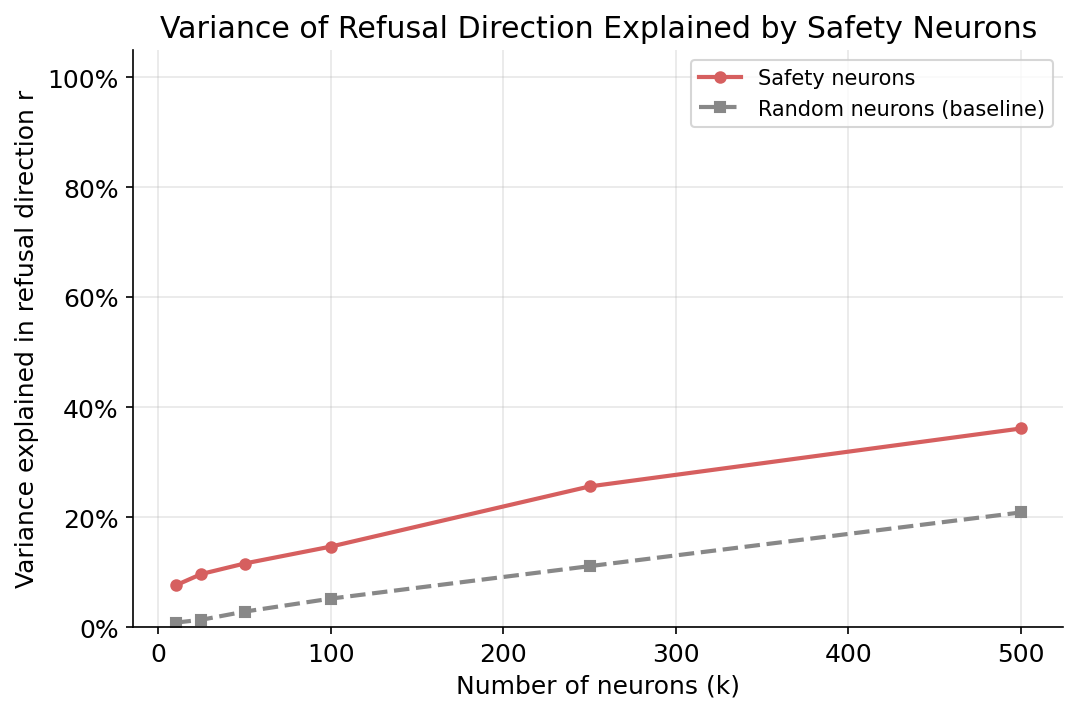

Saved → results/reconstruction_curves.pt


In [7]:
print("Computing reconstruction curve for SAFETY neurons...")
safety_curve = top_neuron_reconstruction(
    model=instruct_model,
    refusal_direction=best_r,
    safety_neurons=top_500,
    ks=k_values,
)

print("\nComputing reconstruction curve for RANDOM neurons (baseline)...")
import random
random.seed(42)
from model_utils import get_intermediate_size
intermediate_size = get_intermediate_size(instruct_model)

random_neurons_500 = [
    (random.randint(0, n_layers - 1), random.randint(0, intermediate_size - 1))
    for _ in range(500)
]

random_curve = top_neuron_reconstruction(
    model=instruct_model,
    refusal_direction=best_r,
    safety_neurons=random_neurons_500,   # ranked list, first k used
    ks=k_values,
)

print("\nReconstruction results:")
print(f"{'k':<8} {'Safety':>10} {'Random':>10} {'Lift':>10}")
print("-" * 42)
for k in k_values:
    lift = safety_curve[k] - random_curve[k]
    print(f"{k:<8} {safety_curve[k]:>10.4f} {random_curve[k]:>10.4f} {lift:>+10.4f}")

fig = plot_reconstruction_curve(
    curve=safety_curve,
    random_curve=random_curve,
    title="Variance of Refusal Direction Explained by Safety Neurons",
    save_path="/kaggle/working/from-neurons-to-directions/exp1_reconstruction_curve.png",
)
plt.show()

torch.save({"safety": safety_curve, "random": random_curve},
           "/kaggle/working/from-neurons-to-directions/reconstruction_curves.pt")
print("Saved → results/reconstruction_curves.pt")

## 6. Layer-wise reconstruction

Does the geometric alignment vary by layer?

For each layer l, we:
  - Take the refusal direction r_l at that layer
  - Take the safety neurons that live in layer l
  - Measure variance of r_l explained by those neurons

This tells us whether certain layers are "hubs" where safety neurons
and the refusal direction coincide, vs layers where they are dissociated.

Computing layer-wise reconstruction...


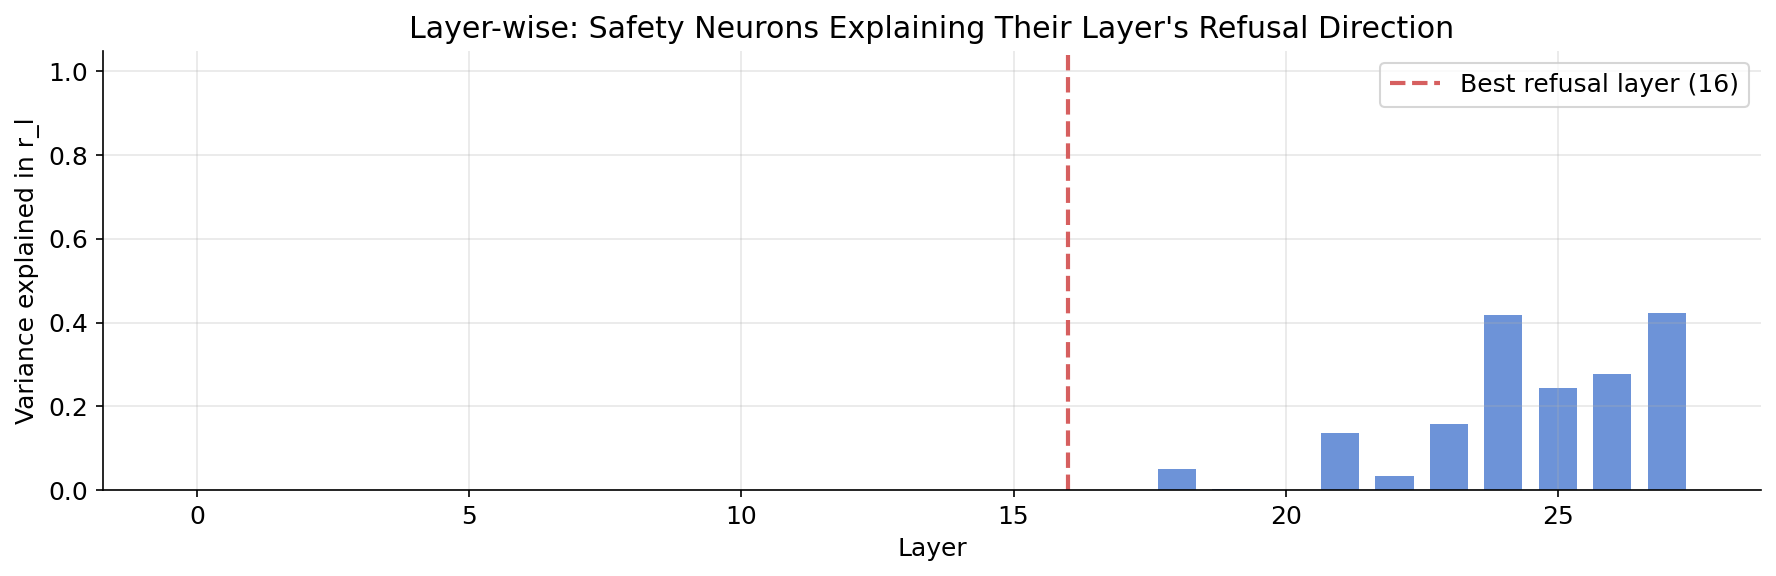

Saved → results/layerwise_reconstruction.pt


In [8]:
print("Computing layer-wise reconstruction...")

layerwise_results = {}

for layer_idx in range(n_layers):
    if (layer_idx, -1) not in directions:
        continue

    best_pos = max(
        (pos for (l, pos) in refusal_scores if l == layer_idx),
        key=lambda pos: refusal_scores[(layer_idx, pos)]
    )

    r_l = directions[(layer_idx, best_pos)]   # refusal direction at this layer

    # Safety neurons in this layer only
    layer_neurons = [
        (l, n) for l, n in top_500 if l == layer_idx
    ]

    if len(layer_neurons) == 0:
        layerwise_results[layer_idx] = 0.0
        continue

    # Get their output vectors
    neuron_indices = [n for _, n in layer_neurons]
    vecs = neuron_output_vectors(instruct_model, layer_idx, neuron_indices)

    ve = variance_explained(r_l, vecs)
    layerwise_results[layer_idx] = ve

# Plot as a bar chart using plot_layer_alignment (repurposing for layer-wise VE)
fig, ax = plt.subplots(figsize=(12, 4))
layers = sorted(layerwise_results.keys())
values = [layerwise_results[l] for l in layers]
ax.bar(layers, values, color="#4878CF", alpha=0.8, width=0.7)
ax.axvline(best_layer, color="#D65F5F", linewidth=2, linestyle="--",
           label=f"Best refusal layer ({best_layer})")
ax.set_xlabel("Layer")
ax.set_ylabel("Variance explained in r_l")
ax.set_title("Layer-wise: Safety Neurons Explaining Their Layer's Refusal Direction")
ax.set_ylim(0, 1.05)
ax.legend()
plt.tight_layout()
plt.savefig("/kaggle/working/from-neurons-to-directions/exp1_layerwise.png", dpi=150)
plt.show()

torch.save(layerwise_results, "/kaggle/working/from-neurons-to-directions/layerwise_reconstruction.pt")
print("Saved → results/layerwise_reconstruction.pt")

## 7. Cross-layer analysis

So far we've kept things layer-local: r_l vs neurons in layer l.
But safety neurons in layer l write into the residual stream, which
then flows into layer l+1, l+2, etc.

Here we ask: do safety neurons from ALL layers together better explain
the refusal direction at the best layer?

If cross-layer neurons explain more than within-layer neurons alone,
it suggests refusal is built up across multiple layers rather than
implemented in one place.

In [9]:
print(f"Cross-layer analysis: all safety neurons → r at layer {best_layer}")

# All 500 safety neurons, regardless of which layer they're in
all_vecs = []
by_layer = {}
for layer_idx, neuron_idx in top_500:
    by_layer.setdefault(layer_idx, []).append(neuron_idx)

for layer_idx, neuron_indices in by_layer.items():
    vecs = neuron_output_vectors(instruct_model, layer_idx, neuron_indices)
    all_vecs.append(vecs)

all_vecs_cat = torch.cat(all_vecs, dim=0)   # [500, hidden_size]
ve_cross = variance_explained(best_r, all_vecs_cat)

# Compare to within-layer only (neurons at best_layer)
best_layer_neurons = [n for l, n in top_500 if l == best_layer]
if best_layer_neurons:
    best_layer_vecs = neuron_output_vectors(instruct_model, best_layer, best_layer_neurons)
    ve_within = variance_explained(best_r, best_layer_vecs)
else:
    ve_within = 0.0

print(f"\nVariance explained in r (layer {best_layer}):")
print(f"  Within-layer neurons only : {ve_within:.4f} ({ve_within:.1%})")
print(f"  All-layer neurons         : {ve_cross:.4f} ({ve_cross:.1%})")
print(f"  Cross-layer gain          : {ve_cross - ve_within:+.4f}")

Cross-layer analysis: all safety neurons → r at layer 16

Variance explained in r (layer 16):
  Within-layer neurons only : 0.0000 (0.0%)
  All-layer neurons         : 0.3611 (36.1%)
  Cross-layer gain          : +0.3611


## 8. Summary and thesis interpretation

Print a structured summary you can copy directly into your thesis notes.

In [10]:
print("=" * 60)
print("EXPERIMENT 1 — GEOMETRIC ALIGNMENT SUMMARY")
print("=" * 60)
print(f"\nRefusal direction r at layer {best_layer}")
print(f"\nPer-neuron alignment (top-500 safety neurons):")
print(f"  Mean |cosine sim| : {sims_t.mean():.4f}")
print(f"  Max  |cosine sim| : {sims_t.max():.4f}")
print(f"  Neurons with |sim| > 0.3 : {(sims_t > 0.3).sum().item()}")

print(f"\nReconstruction curve (variance explained in r):")
for k in k_values:
    print(f"  k={k:<5}: safety={safety_curve[k]:.3f}  random={random_curve[k]:.3f}  "
          f"lift={safety_curve[k]-random_curve[k]:+.3f}")

print(f"\nCross-layer analysis:")
print(f"  Within best layer : {ve_within:.3f}")
print(f"  All layers        : {ve_cross:.3f}")

print(f"\nInterpretation:")
if safety_curve[500] > 0.7:
    print("  HIGH alignment — safety neurons substantially implement r.")
    print("  The two papers describe the same mechanism at different levels.")
elif safety_curve[500] > 0.3:
    print("  MODERATE alignment — safety neurons partially implement r.")
    print("  Other sources (attention, other neurons) also contribute.")
else:
    print("  LOW alignment — mechanisms are geometrically dissociable.")
    print("  r exists but is not primarily written by safety neurons.")
print("=" * 60)
print("\nFiles saved:")
print("  results/neuron_contributions.pt")
print("  results/reconstruction_curves.pt")
print("  results/layerwise_reconstruction.pt")
print("  results/figures/exp1_reconstruction_curve.png")
print("  results/figures/exp1_layerwise.png")
print("\nNext: run 04_exp2_causal_bridge.ipynb")

EXPERIMENT 1 — GEOMETRIC ALIGNMENT SUMMARY

Refusal direction r at layer 16

Per-neuron alignment (top-500 safety neurons):
  Mean |cosine sim| : 0.0664
  Max  |cosine sim| : 0.3984
  Neurons with |sim| > 0.3 : 7

Reconstruction curve (variance explained in r):
  k=10   : safety=0.076  random=0.008  lift=+0.068
  k=25   : safety=0.097  random=0.013  lift=+0.083
  k=50   : safety=0.116  random=0.028  lift=+0.087
  k=100  : safety=0.146  random=0.052  lift=+0.095
  k=250  : safety=0.256  random=0.111  lift=+0.145
  k=500  : safety=0.361  random=0.208  lift=+0.153

Cross-layer analysis:
  Within best layer : 0.000
  All layers        : 0.361

Interpretation:
  MODERATE alignment — safety neurons partially implement r.
  Other sources (attention, other neurons) also contribute.

Files saved:
  results/neuron_contributions.pt
  results/reconstruction_curves.pt
  results/layerwise_reconstruction.pt
  results/figures/exp1_reconstruction_curve.png
  results/figures/exp1_layerwise.png

Next: ru